In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
data=pd.read_csv('Salary_dataset.csv')
data

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [50]:
data.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [51]:
data.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [52]:
data.duplicated().sum()

np.int64(0)

In [53]:
X = data[['YearsExperience']]
y = data['Salary']

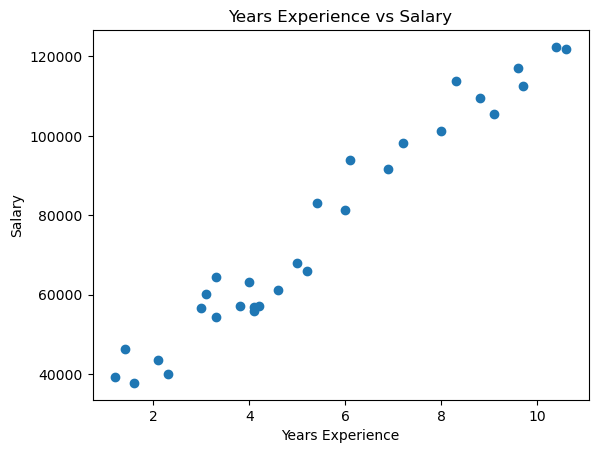

In [54]:
plt.scatter(X, y)
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.title('Years Experience vs Salary')
plt.show()

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [56]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y_pred = model.predict(X_test)

In [58]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 6286.453830757745
MSE: 49830096.855908334
R² Score: 0.9024461774180498


In [59]:
!pip install gradio

  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 1.6 MB/s  0:00:34 eta 0:00:01 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 7.4 MB/s  0:00:00
Using cached click-8.4.2-py3-none-any.whl (119 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 7.2 MB/s  0:00:00m 8.1 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.6 MB/s  0:00:00
  Attempting uninstall: click━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/18 [hf-xet]
    Found existing installation: click 8.2.1;2;249;38;114m╸━━━━━━━━━━━━━━━━━━━━━━━━  7/18 [click]
    Uninstalling click-8.2.1:━━━╸━━━━━━━━━━━━━━━━━━━━━━━━  7/18 [click]
      Successfully uninstalled click-8.2.1;249;38;114m╸━━━━━━━━━━━━━━━━━━━━━━━━  7/18 [click]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [gradio];5;237m━━ 17/18 [gradio]face-hub]


In [60]:
def predict_salary(years_experience):
    prediction = model.predict([[years_experience]])
    return round(prediction[0], 2)

In [61]:
import gradio as gr

app = gr.Interface(
    fn=predict_salary,
    inputs=gr.Number(
        label="Years of Experience",
        value=1
    ),
    outputs=gr.Number(
        label="Predicted Salary"
    ),
    title="💼 Salary Prediction System",
    description="Simple Linear Regression Model for Salary Prediction"
)

app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
